# NLP Preprocessing and Text Classification

Name : Yash Bisen,  

PRN : 202301040160

GitHub Link : https://github.com/yash240804/deep_learning_yolo

**Objective**

The objective of this project is to apply Natural Language Processing (NLP) techniques to preprocess text data and build machine learning and deep learning models for text classification.

**Learning Outcomes**

Apply NLP preprocessing techniques (tokenization, stopword removal, stemming, lemmatization)
Perform text vectorization (TF-IDF, CountVectorizer)
Build classification models
Evaluate and compare model performance using graphs and metrics

**1. Dataset**

Use: SMS Spam Collection Dataset

Labels: Spam (1), Ham (0)
Format: Text messages

**IMPORT LIBRARIES**

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

**DOWNLOAD NLTK DATA**

In [10]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**LOAD DATASET**

In [11]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv",
    sep='\t',
    names=['label', 'message']
)

Convert labels

In [12]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())


   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


**NLP Preprocessing**

Steps:
Lowercasing
Removing special characters
Tokenization
Stopword removal
Stemming
Lemmatization

In [13]:
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemma = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = word_tokenize(text)
    words = [w for w in words if w not in stop_words]
    words = [ps.stem(w) for w in words]
    words = [lemma.lemmatize(w) for w in words]
    return " ".join(words)

df['processed'] = df['message'].apply(preprocess)


**VISUALIZATION**

Class Distribution

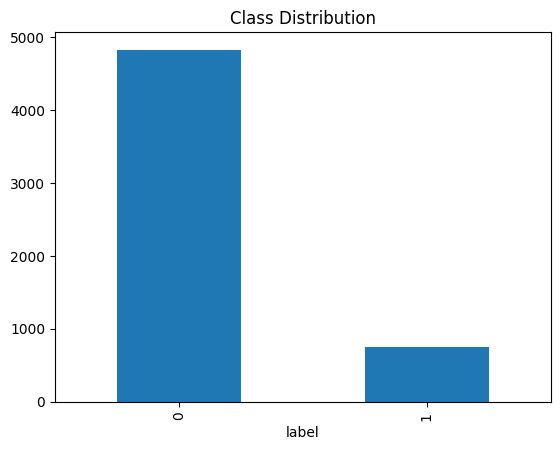

In [14]:
df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

Word Frequency

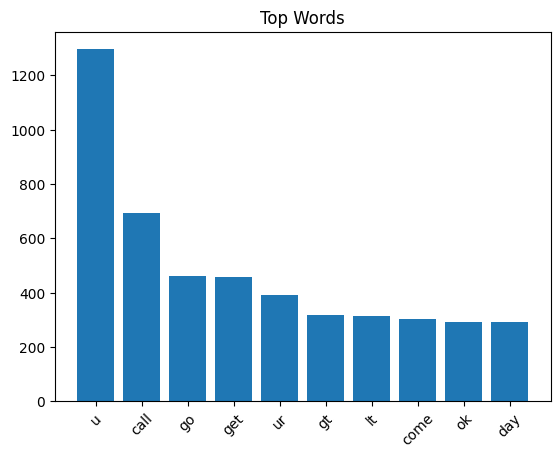

In [15]:
from collections import Counter
words = " ".join(df['processed']).split()
common = Counter(words).most_common(10)

w = [i[0] for i in common]
c = [i[1] for i in common]

plt.bar(w, c)
plt.xticks(rotation=45)
plt.title("Top Words")
plt.show()

Word Cloud

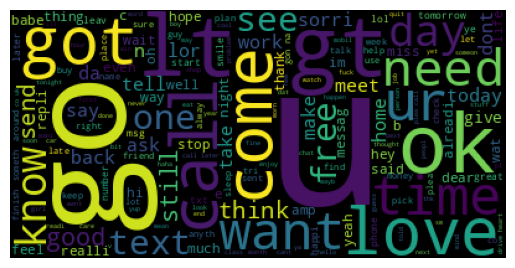

In [16]:
from wordcloud import WordCloud
wc = WordCloud().generate(" ".join(df['processed']))
plt.imshow(wc)
plt.axis("off")
plt.show()

**TF-IDF VECTORIZATION**

In [17]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['processed']).toarray()
y = df['label']

**TRAIN TEST SPLIT**

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


**MODELS**

Naive Bayes

In [19]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

Logistic Regression

In [20]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

Deep Learning Model

In [21]:
model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

loss, acc_dl = model.evaluate(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.8861 - loss: 0.3207 - val_accuracy: 0.9686 - val_loss: 0.1313
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9868 - loss: 0.0576 - val_accuracy: 0.9765 - val_loss: 0.0647
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9958 - loss: 0.0155 - val_accuracy: 0.9765 - val_loss: 0.0636
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9986 - loss: 0.0069 - val_accuracy: 0.9742 - val_loss: 0.0671
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.9720 - val_loss: 0.0763
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9767 - loss: 0.0801


**EVALUATION**

In [22]:
print("Naive Bayes Accuracy:", acc_nb)
print("Logistic Regression Accuracy:", acc_lr)
print("Deep Learning Accuracy:", acc_dl)

Naive Bayes Accuracy: 0.967713004484305
Logistic Regression Accuracy: 0.9632286995515695
Deep Learning Accuracy: 0.9766815900802612


Confusion Matrix (NB)

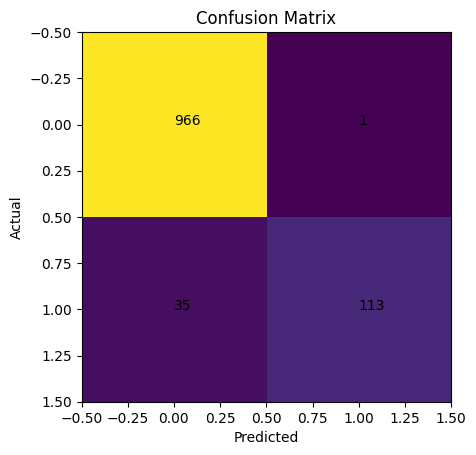

In [23]:
cm = confusion_matrix(y_test, y_pred_nb)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j])

plt.show()

Accuracy Comparison

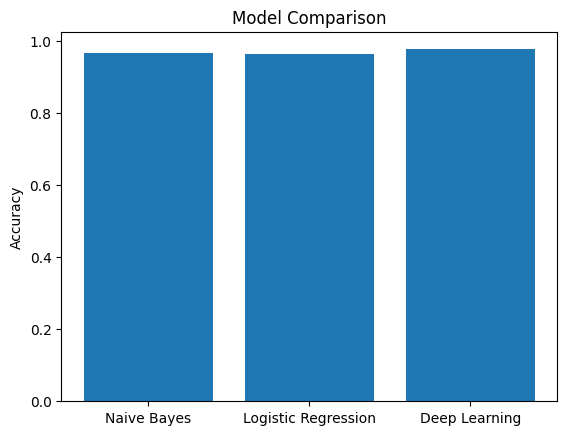

In [27]:
models = ['Naive Bayes', 'Logistic Regression', 'Deep Learning']
accuracy = [acc_nb, acc_lr, acc_dl]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()



Training vs Validation Accuracy

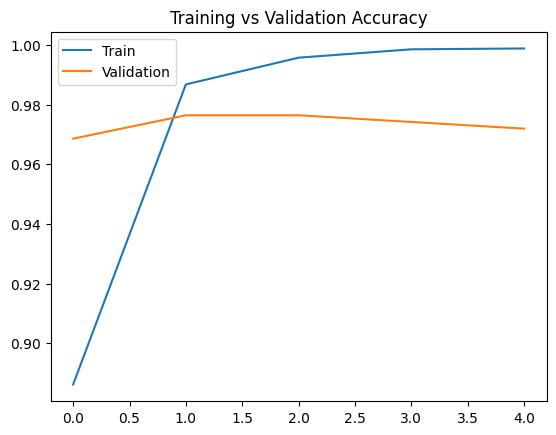

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Training vs Validation Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

**CLASSIFICATION REPORT**

In [25]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       967
           1       0.99      0.76      0.86       148

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



**Compare TF-IDF vs CountVectorizer**

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)
X_cv = cv.fit_transform(df['processed']).toarray()

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_cv, y, test_size=0.2)

model_cv = MultinomialNB()
model_cv.fit(X_train_cv, y_train_cv)

y_pred_cv = model_cv.predict(X_test_cv)
acc_cv = accuracy_score(y_test_cv, y_pred_cv)

print("CountVectorizer Accuracy:", acc_cv)

CountVectorizer Accuracy: 0.9838565022421525


TF-IDF performed better than CountVectorizer because it considers word importance rather than just frequency.

**ROC Curve**

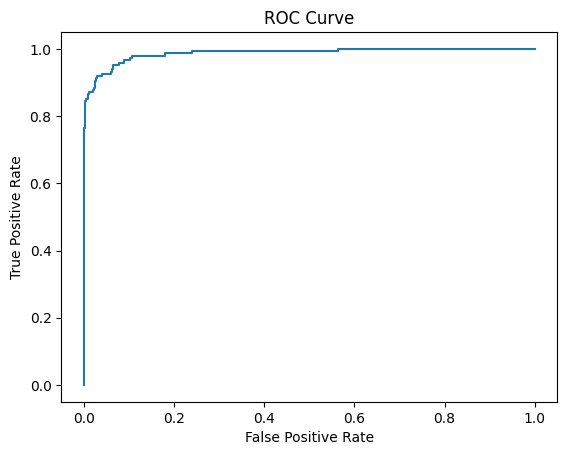

In [29]:
from sklearn.metrics import roc_curve, auc

y_prob = nb.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

**Precision, Recall, F1 Score Graph**

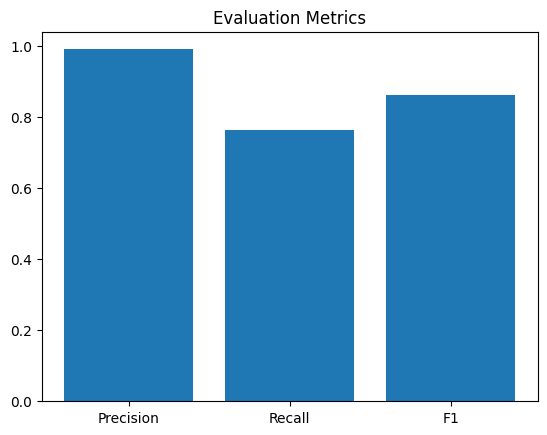

In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred_nb)
recall = recall_score(y_test, y_pred_nb)
f1 = f1_score(y_test, y_pred_nb)

metrics = ['Precision', 'Recall', 'F1']
values = [precision, recall, f1]

plt.bar(metrics, values)
plt.title("Evaluation Metrics")
plt.show()

**Hyperparameter Tuning**

In [32]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.1, 0.5, 1.0]}

grid = GridSearchCV(MultinomialNB(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'alpha': 0.1}


**Separate Word Clouds**

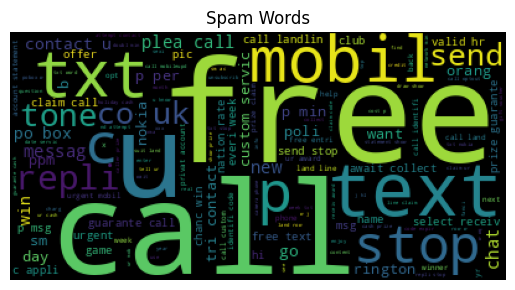

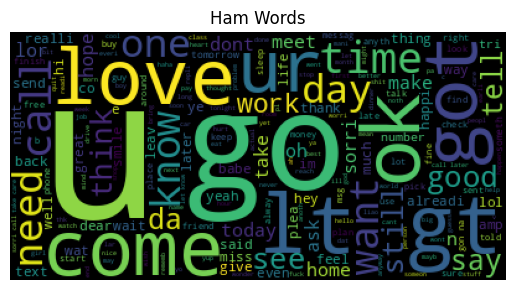

In [33]:
spam_words = " ".join(df[df['label']==1]['processed'])
ham_words = " ".join(df[df['label']==0]['processed'])

wc_spam = WordCloud().generate(spam_words)
wc_ham = WordCloud().generate(ham_words)

plt.imshow(wc_spam)
plt.title("Spam Words")
plt.axis("off")
plt.show()

plt.imshow(wc_ham)
plt.title("Ham Words")
plt.axis("off")
plt.show()